In [2]:
!pip install faker pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.5 MB/s eta 0:00:00


In [3]:
from faker import Faker
import pandas as pd
import random
import datetime
fake = Faker()

In [4]:


# Step 2: Initialize Faker
fake = Faker()

# Step 3: Generate Users Data
users = []

for i in range(100000):  # 50k users
    # Subscription dates
    start_date = fake.date_between(start_date='-5y', end_date='today')
    end_date = start_date + datetime.timedelta(days=random.randint(30, 365))

    # Email: sometimes missing
    email = fake.unique.email()  # guarantees no duplicates
    # Name: messy capitalization
    name = fake.name()
    if random.random() > 0.5:
        name = name.upper()

    # Age: 18–75
    age = random.randint(18, 75)

    # Gender
    gender = random.choice(['Male', 'Female', 'other'])

    # Country
    country = fake.country()

    # Subscription type
    subscription_type = random.choice(['Basic', 'Standard', 'Premium'])

    # Format dates for MySQL
    start_date = start_date.strftime('%Y-%m-%d')
    end_date = end_date.strftime('%Y-%m-%d')

    users.append([
        name,
        email,
        age,
        gender,
        country,
        subscription_type,
        start_date,
        end_date
    ])

# Step 4: Create DataFrame
users_df = pd.DataFrame(users, columns=[
    'name',
    'email',
    'age',
    'gender',
    'country',
    'subscription_type',
    'subscription_start',
    'subscription_end'
])

# Step 5: Save CSV for MySQL
# NULL emails will be saved as NULL (MySQL-compatible)
users_df.to_csv("users.csv", index=False, na_rep='NULL')

# Step 6: Check first 5 rows
users_df.head(10)

,name,email,age,gender,country,subscription_type,subscription_start,subscription_end
0,ALLISON RUIZ,nunezchristopher@example.com,57,Male,Kuwait,Standard,2024-07-02,2025-01-31
1,Nicole Duncan,delgadoashley@example.net,45,Female,Lithuania,Basic,2023-11-21,2024-07-07
2,Julie Sanchez,ahall@example.com,45,Male,Nigeria,Basic,2022-12-20,2023-04-27
3,Ryan Kennedy,unelson@example.org,52,Female,Venezuela,Basic,2022-08-16,2023-02-05
4,Timothy Armstrong,danielnunez@example.com,47,Male,Sierra Leone,Standard,2023-07-07,2024-04-13
5,JENNIFER WILLIAMSON,sharonsawyer@example.org,43,other,French Polynesia,Premium,2023-11-27,2024-06-18
6,EUGENE HAYS,molly78@example.net,60,other,Armenia,Basic,2026-02-02,2026-11-19
7,Eric Whitaker,whitelisa@example.com,20,Female,Botswana,Premium,2024-05-21,2025-02-19
8,LAURIE STONE,kkelly@example.com,26,other,Suriname,Basic,2024-10-01,2025-09-03
9,Christopher Grimes,webbmelanie@example.org,22,Male,Zimbabwe,Basic,2022-10-02,2023-05-11


In [5]:
# Step: Generate View table data
fake = Faker()

genres = ['Action', 'Horror', 'Comedy', 'Drama', 'Sci-Fi', 'Documentary', 'Romance', 'Thriller']

content = []

for i in range(50000):
    title = fake.sentence(nb_words=3).replace('.', '')

    # realistic duration
    duration = round(random.uniform(20, 180), 2)

    # realistic rating (more centered around 3–4)
    rating = round(random.uniform(2.0, 4.8), 1)

    content.append([
        title,
        random.choice(genres),
        duration,
        random.randint(1980, 2025),
        rating
    ])

content_df = pd.DataFrame(content, columns=[
    'title',
    'genre',
    'duration_min',
    'release_year',
    'rating'
])

content_df.head()

,title,genre,duration_min,release_year,rating
0,Just bank beyond,Horror,51.37,2018,2.2
1,Mouth work,Action,115.62,2000,4.5
2,Think cup,Sci-Fi,47.30,2018,2.4
3,A song until wide,Horror,65.60,1983,2.0
4,Individual drive,Comedy,54.08,1988,4.7


In [6]:
# Step: Generate View table data

from faker import Faker
import pandas as pd
import random
import datetime

fake = Faker()

# ---- 1. Define valid IDs ----
# User IDs that actually exist in MySQL users table
valid_user_ids = list(range(172, 100172))  # MIN=172, MAX=100171

# Content IDs that actually exist in MySQL content table
valid_content_ids = list(range(1, 50001))  # assuming 50,000 content rows

# Device types
device_types = ['Mobile', 'Desktop', 'Smart_TV', 'Tablet']

# ---- 2. Generate messy View data ----
view_data = []
num_rows = 300000  # number of view records

for _ in range(num_rows):
    user_id = random.choice(valid_user_ids)           # only valid User_id
    content_id = random.choice(valid_content_ids)    # only valid Content_id
    watch_date = fake.date_time_between(start_date='-5y', end_date='now')
    watch_date_str = watch_date.strftime('%Y-%m-%d %H:%M:%S')  # MySQL datetime format
    watch_time = round(random.uniform(5, 180), 2)   # minutes watched
    device = random.choice(device_types)

    # Append as a row
    view_data.append([user_id, content_id, watch_date_str, watch_time, device])

# ---- 3. Create DataFrame ----
view_df = pd.DataFrame(view_data, columns=[
    'User_id', 'content_id', 'watch_date', 'watch_time_minutes', 'device_type'
])

# ---- 4. Preview ----
print(view_df.head())

# ---- 5. Export to CSV for MySQL LOAD DATA ----
view_df.to_csv("view.csv", index=False, na_rep='NULL')
print("CSV file saved as 'view.csv' ready for MySQL import!")

   User_id  content_id           watch_date  watch_time_minutes device_type
0    92811        6571  2025-05-11 05:56:13               80.23    Smart_TV
1    24570        4312  2022-10-07 21:33:45               85.16    Smart_TV
2      702       18596  2023-10-03 05:25:30                5.46      Tablet
3    60504       35265  2024-04-22 18:40:39               73.83     Desktop
4    15272       19809  2025-11-04 21:18:43              161.93     Desktop
CSV file saved as 'view.csv' ready for MySQL import!


In [7]:
from google.colab import files


In [8]:
users_df.to_csv('users.csv', index=False)
content_df.to_csv('content.csv', index=False)
view_df.to_csv('view.csv', index=False)
files.download('users.csv')
files.download('content.csv')
files.download('view.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns


In [10]:
# display all columns in pandas
pd.set_option('display.max_columns',None)

In [11]:
print('users tables:')
print(users_df.info())
print(users_df.describe)
print(users_df.head())
print(users_df.isnull())

users tables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   name                100000 non-null  object
 1   email               100000 non-null  object
 2   age                 100000 non-null  int64 
 3   gender              100000 non-null  object
 4   country             100000 non-null  object
 5   subscription_type   100000 non-null  object
 6   subscription_start  100000 non-null  object
 7   subscription_end    100000 non-null  object
dtypes: int64(1), object(7)
memory usage: 6.1+ MB
None
<bound method NDFrame.describe of                     name                         email  age  gender  \
0           ALLISON RUIZ  nunezchristopher@example.com   57    Male   
1          Nicole Duncan     delgadoashley@example.net   45  Female   
2          Julie Sanchez             ahall@example.com   45    Male   
3           Ry

In [12]:
# checking missinf users value
print(users_df.isnull().sum())

name                  0
email                 0
age                   0
gender                0
country               0
subscription_type     0
subscription_start    0
subscription_end      0
dtype: int64


In [13]:
# checking types
print(users_df.dtypes)

name                  object
email                 object
age                    int64
gender                object
country               object
subscription_type     object
subscription_start    object
subscription_end      object
dtype: object


In [14]:
# subscription_start and subscription_end still in object so changing in into datetime
users_df['subscription_start'] = pd.to_datetime(users_df['subscription_start'])
users_df['subscription_end'] = pd.to_datetime(users_df['subscription_end'])
# now we wil see datetime
print(users_df.dtypes)

name                          object
email                         object
age                            int64
gender                        object
country                       object
subscription_type             object
subscription_start    datetime64[ns]
subscription_end      datetime64[ns]
dtype: object


In [15]:
# now making gender and subscription_type into categorical

users_df['gender'] = users_df['gender'].astype('category')
users_df['subscription_type'] = users_df['subscription_type'].astype('category')
# now checking dtypes
print(users_df.dtypes)

name                          object
email                         object
age                            int64
gender                      category
country                       object
subscription_type           category
subscription_start    datetime64[ns]
subscription_end      datetime64[ns]
dtype: object


In [16]:
# creating a new feature called subscription_duration
users_df['subscription_duration'] = (
    users_df['subscription_end'] - users_df['subscription_start']
    ).dt.days
print(users_df['subscription_duration'])

0        213
1        229
2        128
3        173
4        281
        ... 
99995     66
99996    319
99997     84
99998    319
99999    344
Name: subscription_duration, Length: 100000, dtype: int64


In [17]:
# creating another new gfeature age_group
users_df['age_group'] = pd.cut (
    users_df['age'],
    bins = [18,25,35,50,65,75],
    labels=['18-25','26-35','36-50','51-65','66-75']
)
print(users_df['age_group'])

0        51-65
1        36-50
2        36-50
3        51-65
4        36-50
         ...  
99995    51-65
99996      NaN
99997    51-65
99998    26-35
99999    51-65
Name: age_group, Length: 100000, dtype: category
Categories (5, object): ['18-25' < '26-35' < '36-50' < '51-65' < '66-75']


In [18]:
# extracting year and month
users_df['start_year'] = users_df['subscription_start'].dt.year
users_df['start_month'] = users_df['subscription_start'].dt.month
print(users_df['start_year'])
print(users_df['start_month'])

0        2024
1        2023
2        2022
3        2022
4        2023
         ... 
99995    2024
99996    2025
99997    2023
99998    2024
99999    2021
Name: start_year, Length: 100000, dtype: int32
0         7
1        11
2        12
3         8
4         7
         ..
99995    11
99996     1
99997     1
99998     4
99999     5
Name: start_month, Length: 100000, dtype: int32


In [19]:
users_df.head(5)

,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month
0,ALLISON RUIZ,nunezchristopher@example.com,57,Male,Kuwait,Standard,2024-07-02,2025-01-31,213,51-65,2024,7
1,Nicole Duncan,delgadoashley@example.net,45,Female,Lithuania,Basic,2023-11-21,2024-07-07,229,36-50,2023,11
2,Julie Sanchez,ahall@example.com,45,Male,Nigeria,Basic,2022-12-20,2023-04-27,128,36-50,2022,12
3,Ryan Kennedy,unelson@example.org,52,Female,Venezuela,Basic,2022-08-16,2023-02-05,173,51-65,2022,8
4,Timothy Armstrong,danielnunez@example.com,47,Male,Sierra Leone,Standard,2023-07-07,2024-04-13,281,36-50,2023,7


In [20]:
# users per subscription type
users_df.groupby('subscription_type').size()

/tmp/ipykernel_20251/642442302.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type').size()


,0
subscription_type,
Basic,33273
Premium,33284
Standard,33443


In [21]:
# most pouplar
users_df.groupby('subscription_type').size().sort_values(ascending = False)


/tmp/ipykernel_20251/3269375069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type').size().sort_values(ascending = False)


,0
subscription_type,
Standard,33443
Premium,33284
Basic,33273


In [22]:
# average subscription day
users_df.groupby('subscription_type')['subscription_duration'].mean().sort_values(ascending = False)

/tmp/ipykernel_20251/3254766896.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type')['subscription_duration'].mean().sort_values(ascending = False)


,subscription_duration
subscription_type,
Basic,198.487873
Premium,197.400282
Standard,197.072661


In [23]:
# combine count and Average

users_df.groupby('subscription_type').agg(
     user_count =('name' , 'count'),
    avg_subscription_duration =( 'subscription_duration' , 'mean')
)


/tmp/ipykernel_20251/3828177484.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_df.groupby('subscription_type').agg(


,user_count,avg_subscription_duration
subscription_type,,
Basic,33273,198.487873
Premium,33284,197.400282
Standard,33443,197.072661


In [24]:
# content table
content_df.head()

,title,genre,duration_min,release_year,rating
0,Just bank beyond,Horror,51.37,2018,2.2
1,Mouth work,Action,115.62,2000,4.5
2,Think cup,Sci-Fi,47.30,2018,2.4
3,A song until wide,Horror,65.60,1983,2.0
4,Individual drive,Comedy,54.08,1988,4.7


In [25]:
content_df. describe()
content_df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         50000 non-null  object 
 1   genre         50000 non-null  object 
 2   duration_min  50000 non-null  float64
 3   release_year  50000 non-null  int64  
 4   rating        50000 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.9+ MB


In [26]:
# converting genre intp category
content_df['genre'].astype('category')

,genre
0,Horror
1,Action
2,Sci-Fi
3,Horror
4,Comedy
...,...
49995,Action
49996,Horror
49997,Comedy
49998,Thriller


In [27]:
# counting
content_df.value_counts('genre')

,count
genre,
Sci-Fi,6321
Documentary,6307
Horror,6296
Action,6293
Romance,6282
Thriller,6203
Drama,6195
Comedy,6103


In [28]:
# avg rating by genre

content_df.groupby('genre')['rating'].mean().sort_values(ascending = False)

,rating
genre,
Documentary,3.418376
Comedy,3.415927
Thriller,3.412510
Romance,3.409742
Sci-Fi,3.408701
Action,3.406595
Drama,3.398483
Horror,3.392630


In [29]:
# avg duration by genre

content_df.groupby('genre')['duration_min'].mean().sort_values(ascending = False)

,duration_min
genre,
Documentary,100.898311
Comedy,100.826715
Action,100.788808
Romance,100.329753
Drama,100.234324
Horror,99.929390
Thriller,99.809887
Sci-Fi,99.502071


In [30]:
# view table
view_df.head()


,User_id,content_id,watch_date,watch_time_minutes,device_type
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV
2,702,18596,2023-10-03 05:25:30,5.46,Tablet
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop


In [31]:
view_df.describe()
view_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   User_id             300000 non-null  int64  
 1   content_id          300000 non-null  int64  
 2   watch_date          300000 non-null  object 
 3   watch_time_minutes  300000 non-null  float64
 4   device_type         300000 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 11.4+ MB


In [32]:
view_df['watch_date'] = pd.to_datetime(view_df['watch_date'],errors='coerce')
print(view_df)

        User_id  content_id          watch_date  watch_time_minutes  \
0         92811        6571 2025-05-11 05:56:13               80.23   
1         24570        4312 2022-10-07 21:33:45               85.16   
2           702       18596 2023-10-03 05:25:30                5.46   
3         60504       35265 2024-04-22 18:40:39               73.83   
4         15272       19809 2025-11-04 21:18:43              161.93   
...         ...         ...                 ...                 ...   
299995    26251       26911 2025-05-02 05:39:25               14.51   
299996    83439       45748 2024-10-14 10:07:14               10.31   
299997    74847       20679 2025-09-21 01:15:57               73.32   
299998    52070       39527 2023-06-27 14:33:33              167.07   
299999     2472       24559 2021-06-11 23:36:22              157.12   

       device_type  
0         Smart_TV  
1         Smart_TV  
2           Tablet  
3          Desktop  
4          Desktop  
...            ...  


In [33]:
# add useful columns
view_df['watch_year'] = view_df['watch_date'].dt.year
view_df['watch_month'] = view_df['watch_date'].dt.month
view_df['watch_dayofweek'] = view_df['watch_date'].dt.day_name()
view_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday
...,...,...,...,...,...,...,...,...
299995,26251,26911,2025-05-02 05:39:25,14.51,Tablet,2025,5,Friday
299996,83439,45748,2024-10-14 10:07:14,10.31,Tablet,2024,10,Monday
299997,74847,20679,2025-09-21 01:15:57,73.32,Tablet,2025,9,Sunday
299998,52070,39527,2023-06-27 14:33:33,167.07,Desktop,2023,6,Tuesday


In [34]:
# checking
view_df['device_type'].value_counts()


,count
device_type,
Desktop,75179
Smart_TV,75021
Tablet,74935
Mobile,74865


In [35]:
# checking

view_df['watch_year'].value_counts().sort_values(ascending = False)

,count
watch_year,
2024,60276
2022,60141
2025,60006
2023,59516
2021,43574
2026,16487


In [36]:
print(users_df.columns)
print(view_df.columns)

Index(['name', 'email', 'age', 'gender', 'country', 'subscription_type',
       'subscription_start', 'subscription_end', 'subscription_duration',
       'age_group', 'start_year', 'start_month'],
      dtype='object')
Index(['User_id', 'content_id', 'watch_date', 'watch_time_minutes',
       'device_type', 'watch_year', 'watch_month', 'watch_dayofweek'],
      dtype='object')


In [37]:
# Step 1: Add content_id to content_df
content_df['content_id'] = range(1, len(content_df)+1)

# Step 2: Merge users and view (ensure users_df has User_id)
users_df['User_id'] = range(1, len(users_df)+1)
user_view_df = view_df.merge(users_df, on='User_id', how='left')

# Step 3: Merge the above with content_df
full_df = user_view_df.merge(content_df, on='content_id', how='left')

# Step 4: Check the merged dataframe
full_df.head()

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday,PAUL OBRIEN,wrightjohn@example.com,26.0,Male,Barbados,Basic,2024-01-26,2024-11-05,284.0,26-35,2024.0,1.0,Executive ball scientist,Action,59.87,2005,4.5
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday,RICHARD RIVERA,richard89@example.net,33.0,other,Andorra,Standard,2023-11-07,2024-05-15,190.0,26-35,2023.0,11.0,Choose garden bag,Comedy,103.25,1986,3.1
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday,Terry Simon,tonya65@example.com,47.0,Female,Germany,Basic,2024-05-20,2024-07-13,54.0,36-50,2024.0,5.0,Mr long stock,Documentary,102.36,2023,2.2
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday,TAMMY BOWMAN,suzanne35@example.com,26.0,other,Italy,Basic,2024-03-05,2024-12-17,287.0,26-35,2024.0,3.0,Partner game,Documentary,43.77,1994,4.4
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday,Ian Mccarthy,ktrevino@example.org,22.0,Female,Panama,Premium,2023-12-17,2024-04-20,125.0,18-25,2023.0,12.0,Writer middle,Romance,117.52,1989,3.5


In [38]:
# checking missing values
full_df.isnull().sum()


,0
User_id,0
content_id,0
watch_date,0
watch_time_minutes,0
device_type,0
watch_year,0
watch_month,0
watch_dayofweek,0
name,524
email,524


In [39]:
# changes into category
full_df['genre'].astype('category')
full_df['gender'].astype('category')
full_df['country'].astype('category')
full_df['subscription_type'].astype('category')
full_df['device_type'].astype('category')

,device_type
0,Smart_TV
1,Smart_TV
2,Tablet
3,Desktop
4,Desktop
...,...
299995,Tablet
299996,Tablet
299997,Tablet
299998,Desktop


In [40]:
full_df['subscription_start'] = pd.to_datetime(full_df['subscription_start'])
full_df['subscription_end'] = pd.to_datetime(full_df['subscription_end'])
full_df['watch_date'] = pd.to_datetime(full_df['watch_date'])
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday,PAUL OBRIEN,wrightjohn@example.com,26.0,Male,Barbados,Basic,2024-01-26,2024-11-05,284.0,26-35,2024.0,1.0,Executive ball scientist,Action,59.87,2005,4.5
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday,RICHARD RIVERA,richard89@example.net,33.0,other,Andorra,Standard,2023-11-07,2024-05-15,190.0,26-35,2023.0,11.0,Choose garden bag,Comedy,103.25,1986,3.1
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday,Terry Simon,tonya65@example.com,47.0,Female,Germany,Basic,2024-05-20,2024-07-13,54.0,36-50,2024.0,5.0,Mr long stock,Documentary,102.36,2023,2.2
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday,TAMMY BOWMAN,suzanne35@example.com,26.0,other,Italy,Basic,2024-03-05,2024-12-17,287.0,26-35,2024.0,3.0,Partner game,Documentary,43.77,1994,4.4
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday,Ian Mccarthy,ktrevino@example.org,22.0,Female,Panama,Premium,2023-12-17,2024-04-20,125.0,18-25,2023.0,12.0,Writer middle,Romance,117.52,1989,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,26251,26911,2025-05-02 05:39:25,14.51,Tablet,2025,5,Friday,Kevin Gibson,coreyryan@example.net,75.0,Male,Belize,Basic,2023-12-15,2024-02-04,51.0,66-75,2023.0,12.0,Shake seven,Documentary,68.94,1985,3.2
299996,83439,45748,2024-10-14 10:07:14,10.31,Tablet,2024,10,Monday,Tyler Huffman,qspencer@example.net,73.0,Female,Belarus,Standard,2024-11-24,2025-02-04,72.0,66-75,2024.0,11.0,Service agree,Thriller,154.27,1995,3.9
299997,74847,20679,2025-09-21 01:15:57,73.32,Tablet,2025,9,Sunday,KEVIN LOGAN,jerryparker@example.com,33.0,other,United States Virgin Islands,Standard,2024-11-19,2025-08-23,277.0,26-35,2024.0,11.0,Challenge,Horror,32.19,2013,3.4
299998,52070,39527,2023-06-27 14:33:33,167.07,Desktop,2023,6,Tuesday,GARY RAMIREZ,umorales@example.com,25.0,Male,Anguilla,Standard,2026-01-05,2026-10-13,281.0,18-25,2026.0,1.0,Executive sport,Romance,56.92,2003,2.4


In [41]:
# Feature Engineering : Subscription duration in  days
full_df['subscription_days'] = (full_df['subscription_end'] - full_df['subscription_start']).dt.days
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday,PAUL OBRIEN,wrightjohn@example.com,26.0,Male,Barbados,Basic,2024-01-26,2024-11-05,284.0,26-35,2024.0,1.0,Executive ball scientist,Action,59.87,2005,4.5,284.0
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday,RICHARD RIVERA,richard89@example.net,33.0,other,Andorra,Standard,2023-11-07,2024-05-15,190.0,26-35,2023.0,11.0,Choose garden bag,Comedy,103.25,1986,3.1,190.0
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday,Terry Simon,tonya65@example.com,47.0,Female,Germany,Basic,2024-05-20,2024-07-13,54.0,36-50,2024.0,5.0,Mr long stock,Documentary,102.36,2023,2.2,54.0
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday,TAMMY BOWMAN,suzanne35@example.com,26.0,other,Italy,Basic,2024-03-05,2024-12-17,287.0,26-35,2024.0,3.0,Partner game,Documentary,43.77,1994,4.4,287.0
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday,Ian Mccarthy,ktrevino@example.org,22.0,Female,Panama,Premium,2023-12-17,2024-04-20,125.0,18-25,2023.0,12.0,Writer middle,Romance,117.52,1989,3.5,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,26251,26911,2025-05-02 05:39:25,14.51,Tablet,2025,5,Friday,Kevin Gibson,coreyryan@example.net,75.0,Male,Belize,Basic,2023-12-15,2024-02-04,51.0,66-75,2023.0,12.0,Shake seven,Documentary,68.94,1985,3.2,51.0
299996,83439,45748,2024-10-14 10:07:14,10.31,Tablet,2024,10,Monday,Tyler Huffman,qspencer@example.net,73.0,Female,Belarus,Standard,2024-11-24,2025-02-04,72.0,66-75,2024.0,11.0,Service agree,Thriller,154.27,1995,3.9,72.0
299997,74847,20679,2025-09-21 01:15:57,73.32,Tablet,2025,9,Sunday,KEVIN LOGAN,jerryparker@example.com,33.0,other,United States Virgin Islands,Standard,2024-11-19,2025-08-23,277.0,26-35,2024.0,11.0,Challenge,Horror,32.19,2013,3.4,277.0
299998,52070,39527,2023-06-27 14:33:33,167.07,Desktop,2023,6,Tuesday,GARY RAMIREZ,umorales@example.com,25.0,Male,Anguilla,Standard,2026-01-05,2026-10-13,281.0,18-25,2026.0,1.0,Executive sport,Romance,56.92,2003,2.4,281.0


In [42]:
# feature Engineering : age group
bins = [0, 18, 30, 45, 60, 100]
labels = ['<18', '18-30', '31-45', '46-60', '60+']
full_df['age_group'] = pd.cut(full_df['age'], bins=bins, labels=labels)
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday,PAUL OBRIEN,wrightjohn@example.com,26.0,Male,Barbados,Basic,2024-01-26,2024-11-05,284.0,18-30,2024.0,1.0,Executive ball scientist,Action,59.87,2005,4.5,284.0
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday,RICHARD RIVERA,richard89@example.net,33.0,other,Andorra,Standard,2023-11-07,2024-05-15,190.0,31-45,2023.0,11.0,Choose garden bag,Comedy,103.25,1986,3.1,190.0
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday,Terry Simon,tonya65@example.com,47.0,Female,Germany,Basic,2024-05-20,2024-07-13,54.0,46-60,2024.0,5.0,Mr long stock,Documentary,102.36,2023,2.2,54.0
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday,TAMMY BOWMAN,suzanne35@example.com,26.0,other,Italy,Basic,2024-03-05,2024-12-17,287.0,18-30,2024.0,3.0,Partner game,Documentary,43.77,1994,4.4,287.0
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday,Ian Mccarthy,ktrevino@example.org,22.0,Female,Panama,Premium,2023-12-17,2024-04-20,125.0,18-30,2023.0,12.0,Writer middle,Romance,117.52,1989,3.5,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,26251,26911,2025-05-02 05:39:25,14.51,Tablet,2025,5,Friday,Kevin Gibson,coreyryan@example.net,75.0,Male,Belize,Basic,2023-12-15,2024-02-04,51.0,60+,2023.0,12.0,Shake seven,Documentary,68.94,1985,3.2,51.0
299996,83439,45748,2024-10-14 10:07:14,10.31,Tablet,2024,10,Monday,Tyler Huffman,qspencer@example.net,73.0,Female,Belarus,Standard,2024-11-24,2025-02-04,72.0,60+,2024.0,11.0,Service agree,Thriller,154.27,1995,3.9,72.0
299997,74847,20679,2025-09-21 01:15:57,73.32,Tablet,2025,9,Sunday,KEVIN LOGAN,jerryparker@example.com,33.0,other,United States Virgin Islands,Standard,2024-11-19,2025-08-23,277.0,31-45,2024.0,11.0,Challenge,Horror,32.19,2013,3.4,277.0
299998,52070,39527,2023-06-27 14:33:33,167.07,Desktop,2023,6,Tuesday,GARY RAMIREZ,umorales@example.com,25.0,Male,Anguilla,Standard,2026-01-05,2026-10-13,281.0,18-30,2026.0,1.0,Executive sport,Romance,56.92,2003,2.4,281.0


In [43]:
# Watch day of week, month, year
full_df['watch_year'] = full_df['watch_date'].dt.year
full_df['watch_month'] = full_df['watch_date'].dt.month
full_df['watch_dayofweek'] = full_df['watch_date'].dt.day_name()
full_df

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday,PAUL OBRIEN,wrightjohn@example.com,26.0,Male,Barbados,Basic,2024-01-26,2024-11-05,284.0,18-30,2024.0,1.0,Executive ball scientist,Action,59.87,2005,4.5,284.0
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday,RICHARD RIVERA,richard89@example.net,33.0,other,Andorra,Standard,2023-11-07,2024-05-15,190.0,31-45,2023.0,11.0,Choose garden bag,Comedy,103.25,1986,3.1,190.0
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday,Terry Simon,tonya65@example.com,47.0,Female,Germany,Basic,2024-05-20,2024-07-13,54.0,46-60,2024.0,5.0,Mr long stock,Documentary,102.36,2023,2.2,54.0
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday,TAMMY BOWMAN,suzanne35@example.com,26.0,other,Italy,Basic,2024-03-05,2024-12-17,287.0,18-30,2024.0,3.0,Partner game,Documentary,43.77,1994,4.4,287.0
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday,Ian Mccarthy,ktrevino@example.org,22.0,Female,Panama,Premium,2023-12-17,2024-04-20,125.0,18-30,2023.0,12.0,Writer middle,Romance,117.52,1989,3.5,125.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,26251,26911,2025-05-02 05:39:25,14.51,Tablet,2025,5,Friday,Kevin Gibson,coreyryan@example.net,75.0,Male,Belize,Basic,2023-12-15,2024-02-04,51.0,60+,2023.0,12.0,Shake seven,Documentary,68.94,1985,3.2,51.0
299996,83439,45748,2024-10-14 10:07:14,10.31,Tablet,2024,10,Monday,Tyler Huffman,qspencer@example.net,73.0,Female,Belarus,Standard,2024-11-24,2025-02-04,72.0,60+,2024.0,11.0,Service agree,Thriller,154.27,1995,3.9,72.0
299997,74847,20679,2025-09-21 01:15:57,73.32,Tablet,2025,9,Sunday,KEVIN LOGAN,jerryparker@example.com,33.0,other,United States Virgin Islands,Standard,2024-11-19,2025-08-23,277.0,31-45,2024.0,11.0,Challenge,Horror,32.19,2013,3.4,277.0
299998,52070,39527,2023-06-27 14:33:33,167.07,Desktop,2023,6,Tuesday,GARY RAMIREZ,umorales@example.com,25.0,Male,Anguilla,Standard,2026-01-05,2026-10-13,281.0,18-30,2026.0,1.0,Executive sport,Romance,56.92,2003,2.4,281.0


In [44]:
# check consistency
full_df.describe()

,User_id,content_id,watch_date,watch_time_minutes,watch_year,watch_month,age,subscription_start,subscription_end,subscription_duration,start_year,start_month,duration_min,release_year,rating,subscription_days
count,300000.000000,300000.000000,300000,300000.000000,300000.000000,300000.000000,299476.000000,299476,299476,299476.000000,299476.000000,299476.000000,300000.000000,300000.000000,300000.000000,299476.000000
mean,50118.822277,24969.679973,2023-10-10 23:52:41.125777152,92.498244,2023.274867,6.518040,46.453826,2023-10-12 06:49:39.668487424,2024-04-26 17:54:09.467736832,197.461456,2023.280530,6.507814,100.285155,2002.570823,3.407155,197.461456
min,172.000000,1.000000,2021-04-10 18:07:10,5.000000,2021.000000,1.000000,18.000000,2021-04-09 00:00:00,2021-05-13 00:00:00,30.000000,2021.000000,1.000000,20.000000,1980.000000,2.000000,30.000000
25%,25086.750000,12479.000000,2022-07-10 01:14:18.500000,48.760000,2022.000000,4.000000,32.000000,2022-07-11 00:00:00,2023-01-25 00:00:00,113.000000,2022.000000,4.000000,60.550000,1991.000000,2.700000,113.000000
50%,50046.000000,24994.000000,2023-10-12 13:07:42,92.540000,2023.000000,7.000000,46.000000,2023-10-14 00:00:00,2024-04-30 00:00:00,198.000000,2023.000000,7.000000,100.680000,2003.000000,3.400000,198.000000
75%,75117.000000,37459.250000,2025-01-10 05:49:56.750000128,136.220000,2025.000000,10.000000,61.000000,2025-01-13 00:00:00,2025-07-28 00:00:00,282.000000,2025.000000,9.000000,140.140000,2014.000000,4.100000,282.000000
max,100171.000000,50000.000000,2026-04-10 22:31:30,180.000000,2026.000000,12.000000,75.000000,2026-04-09 00:00:00,2027-04-06 00:00:00,365.000000,2026.000000,12.000000,180.000000,2025.000000,4.800000,365.000000
std,28868.291775,14431.896508,NaN,50.521322,1.483753,3.449556,16.744037,NaN,NaN,97.127019,1.482419,3.445025,46.062865,13.248892,0.810172,97.127019


In [45]:
full_df.head()

,User_id,content_id,watch_date,watch_time_minutes,device_type,watch_year,watch_month,watch_dayofweek,name,email,age,gender,country,subscription_type,subscription_start,subscription_end,subscription_duration,age_group,start_year,start_month,title,genre,duration_min,release_year,rating,subscription_days
0,92811,6571,2025-05-11 05:56:13,80.23,Smart_TV,2025,5,Sunday,PAUL OBRIEN,wrightjohn@example.com,26.0,Male,Barbados,Basic,2024-01-26,2024-11-05,284.0,18-30,2024.0,1.0,Executive ball scientist,Action,59.87,2005,4.5,284.0
1,24570,4312,2022-10-07 21:33:45,85.16,Smart_TV,2022,10,Friday,RICHARD RIVERA,richard89@example.net,33.0,other,Andorra,Standard,2023-11-07,2024-05-15,190.0,31-45,2023.0,11.0,Choose garden bag,Comedy,103.25,1986,3.1,190.0
2,702,18596,2023-10-03 05:25:30,5.46,Tablet,2023,10,Tuesday,Terry Simon,tonya65@example.com,47.0,Female,Germany,Basic,2024-05-20,2024-07-13,54.0,46-60,2024.0,5.0,Mr long stock,Documentary,102.36,2023,2.2,54.0
3,60504,35265,2024-04-22 18:40:39,73.83,Desktop,2024,4,Monday,TAMMY BOWMAN,suzanne35@example.com,26.0,other,Italy,Basic,2024-03-05,2024-12-17,287.0,18-30,2024.0,3.0,Partner game,Documentary,43.77,1994,4.4,287.0
4,15272,19809,2025-11-04 21:18:43,161.93,Desktop,2025,11,Tuesday,Ian Mccarthy,ktrevino@example.org,22.0,Female,Panama,Premium,2023-12-17,2024-04-20,125.0,18-30,2023.0,12.0,Writer middle,Romance,117.52,1989,3.5,125.0


/tmp/ipykernel_20251/1025720186.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")


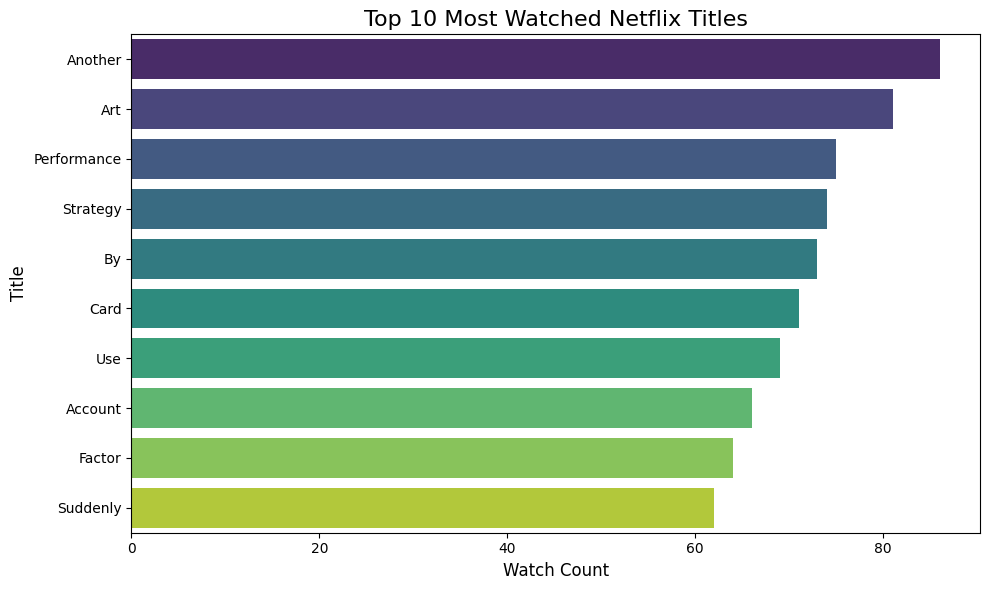

In [46]:
# full_df is our cleaned DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
# Top 10 Most Watched Titles
top_titles = full_df['title'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_titles.values, y=top_titles.index, palette="viridis")
plt.title('Top 10 Most Watched Netflix Titles', fontsize=16)
plt.xlabel('Watch Count', fontsize=12)
plt.ylabel('Title', fontsize=12)
plt.tight_layout()
plt.show()


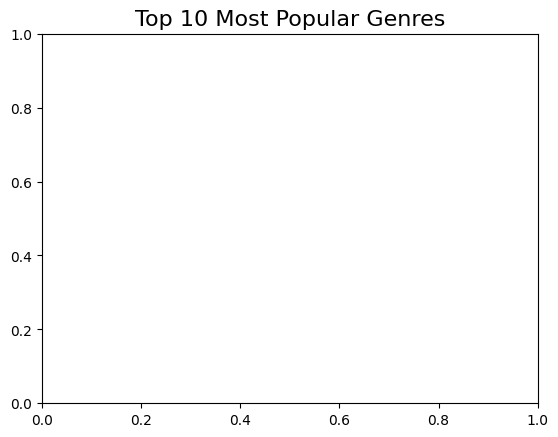

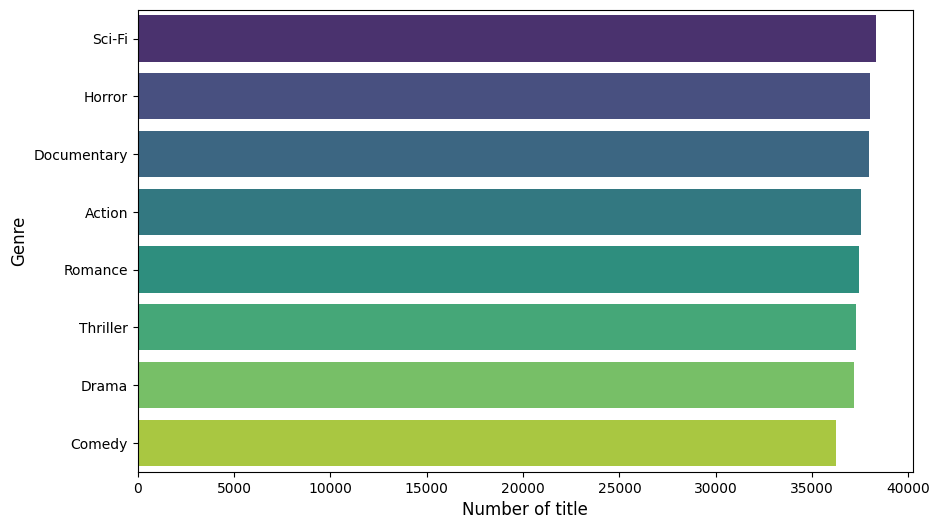

In [47]:
# Genre Popularity
genre_count = full_df['genre'].value_counts().head(10)
plt.title("Top 10 Most Popular Genres", fontsize = 16)
plt.figure(figsize = (10,6))
sns.barplot(
    x=genre_count.values,
    y=genre_count.index,
    hue=genre_count.index,   # assign hue
    palette="viridis",
    legend=False )            # remove extra legend
plt.xlabel('Number of title', fontsize = 12)
plt.ylabel('Genre', fontsize = 12)
plt.tight_layout
plt.show()

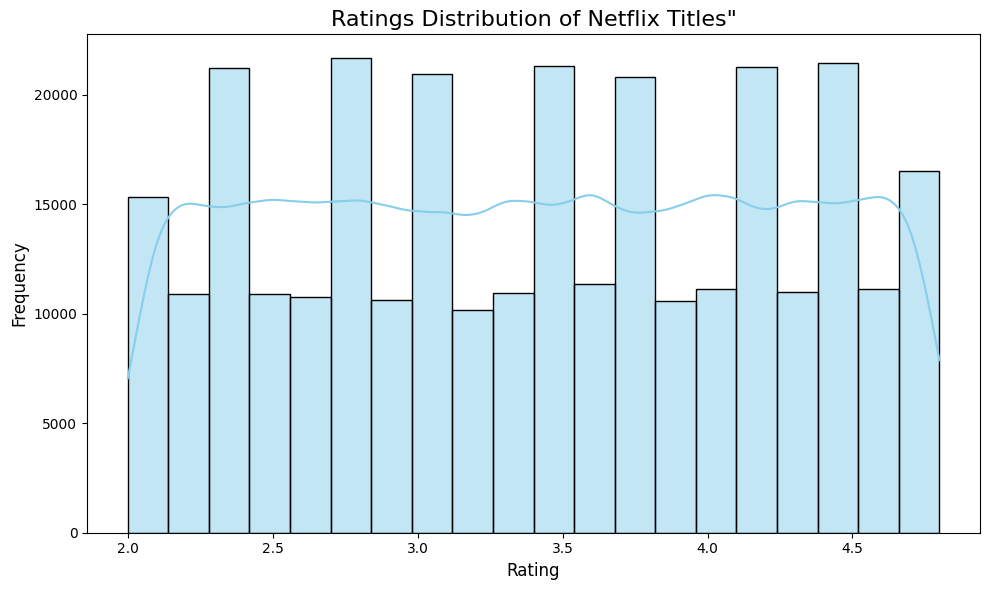

In [48]:
# Rating distribution
plt.figure(figsize=(10,6))
sns.histplot(full_df['rating'], bins=20, kde=True, color='skyblue')
plt.title('Ratings Distribution of Netflix Titles"', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

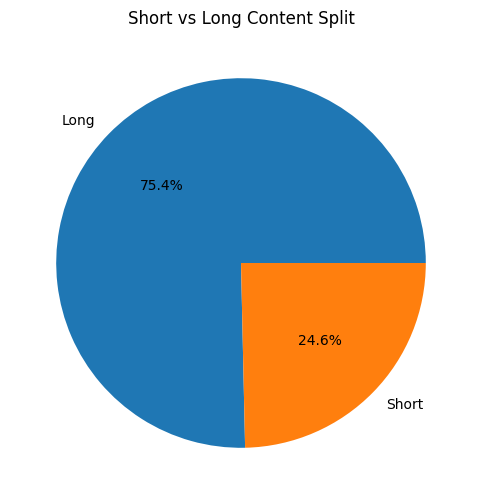

In [49]:
# Long vs Short Content Split
full_df['content_length'] = full_df['duration_min'].apply(
    lambda x: 'Short' if x < 60 else 'Long'
)

length_count = full_df['content_length'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(length_count, labels=length_count.index, autopct='%1.1f%%')
plt.title('Short vs Long Content Split')
plt.show()

/tmp/ipykernel_20251/590265937.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_watch = full_df.groupby('age_group')['watch_time_minutes'].sum()


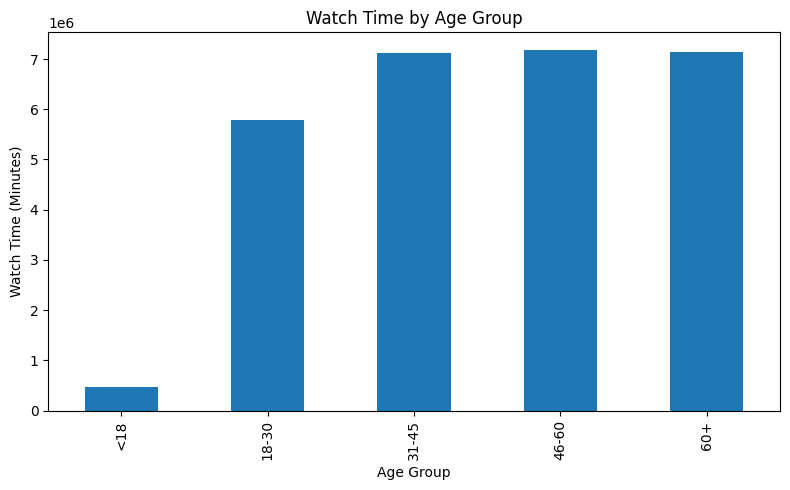

In [50]:
# age group Engagement
age_watch = full_df.groupby('age_group')['watch_time_minutes'].sum()

plt.figure(figsize=(8,5))
age_watch.plot(kind='bar')
plt.title('Watch Time by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Watch Time (Minutes)')
plt.tight_layout()
plt.show()

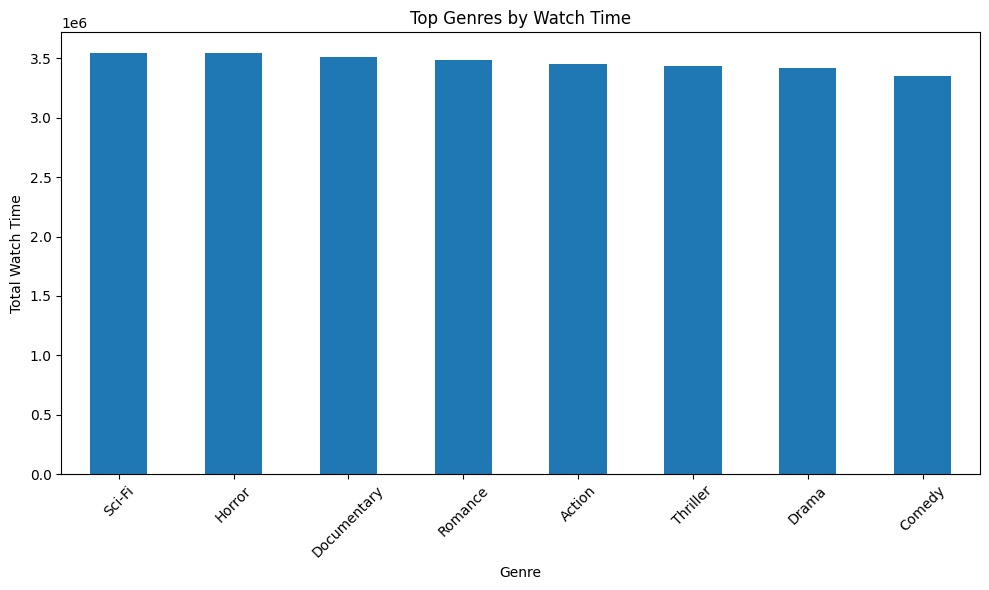

In [51]:
# Top Genres by Watch Time
genre_watch = full_df.groupby('genre')['watch_time_minutes'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
genre_watch.plot(kind='bar')
plt.title('Top Genres by Watch Time')
plt.xlabel('Genre')
plt.ylabel('Total Watch Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_20251/327124008.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_watch = full_df.groupby('subscription_type')['watch_time_minutes'].sum()


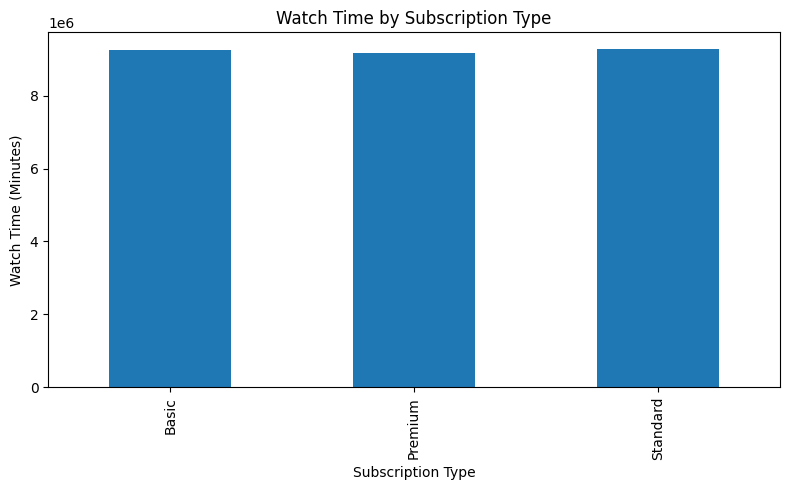

In [52]:
# Watch Time by Subscription Type
sub_watch = full_df.groupby('subscription_type')['watch_time_minutes'].sum()

plt.figure(figsize=(8,5))
sub_watch.plot(kind='bar')
plt.title('Watch Time by Subscription Type')
plt.xlabel('Subscription Type')
plt.ylabel('Watch Time (Minutes)')
plt.tight_layout()
plt.show()

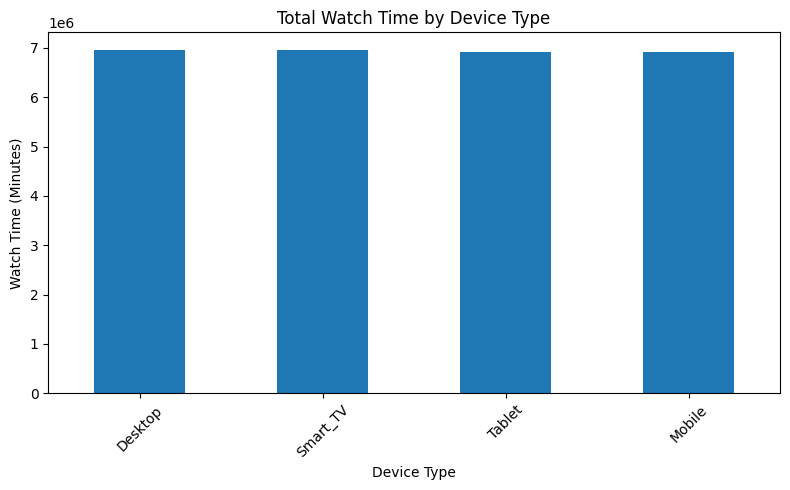

In [53]:
# Watch Time by Device Type
device_watch = full_df.groupby('device_type')['watch_time_minutes'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
device_watch.plot(kind='bar')
plt.title('Total Watch Time by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Watch Time (Minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

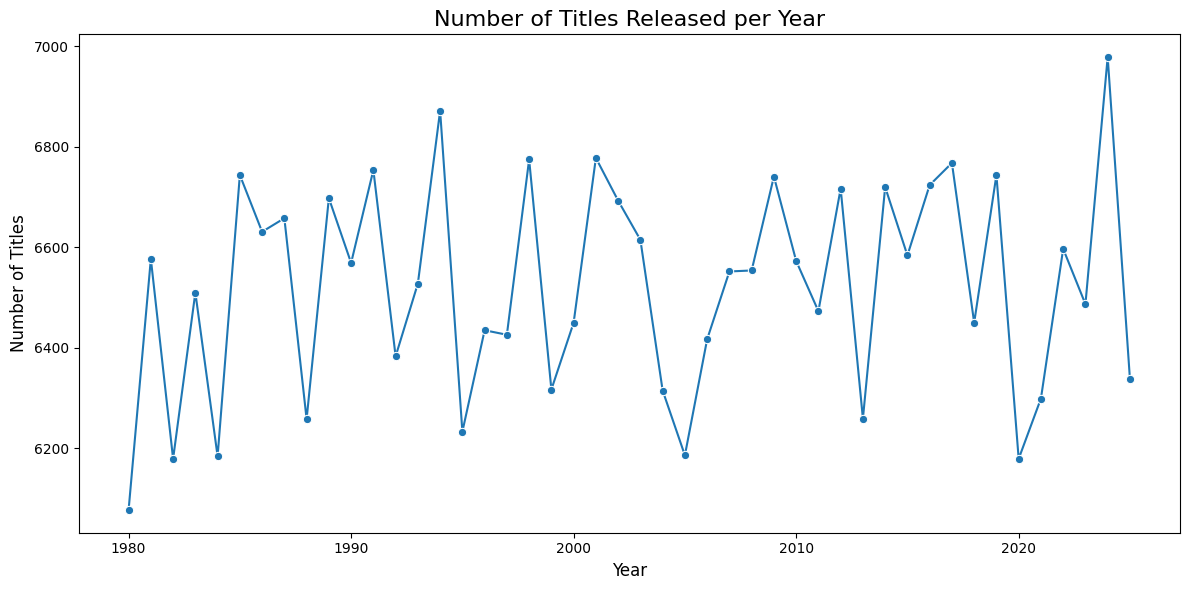

In [54]:
# Watch Count per Year
if 'release_year' in full_df.columns:
    yearly_count = full_df['release_year'].value_counts().sort_index()
    plt.figure(figsize=(12,6))
    sns.lineplot(x=yearly_count.index, y=yearly_count.values, marker='o')
    plt.title('Number of Titles Released per Year', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Number of Titles', fontsize=12)
    plt.tight_layout()
    plt.show()

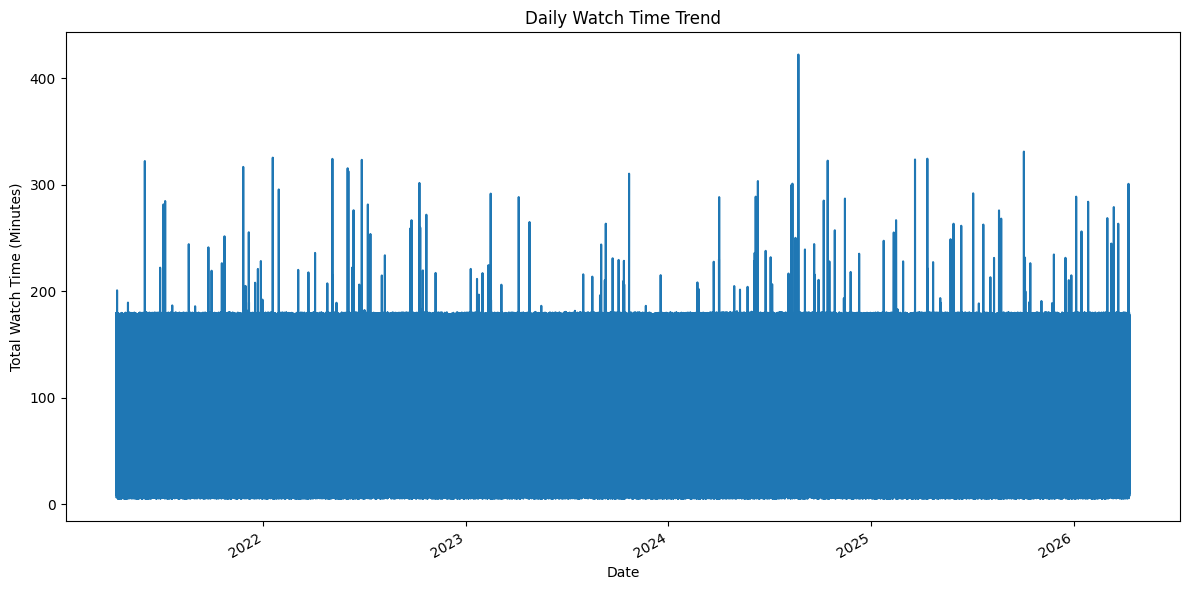

In [55]:
# Aggregate daily watch time
daily_trend = full_df.groupby('watch_date')['watch_time_minutes'].sum()

plt.figure(figsize=(12,6))
daily_trend.plot()
plt.title('Daily Watch Time Trend')
plt.xlabel('Date')
plt.ylabel('Total Watch Time (Minutes)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_20251/772850901.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = full_df.resample('M', on='watch_date')['watch_time_minutes'].sum()


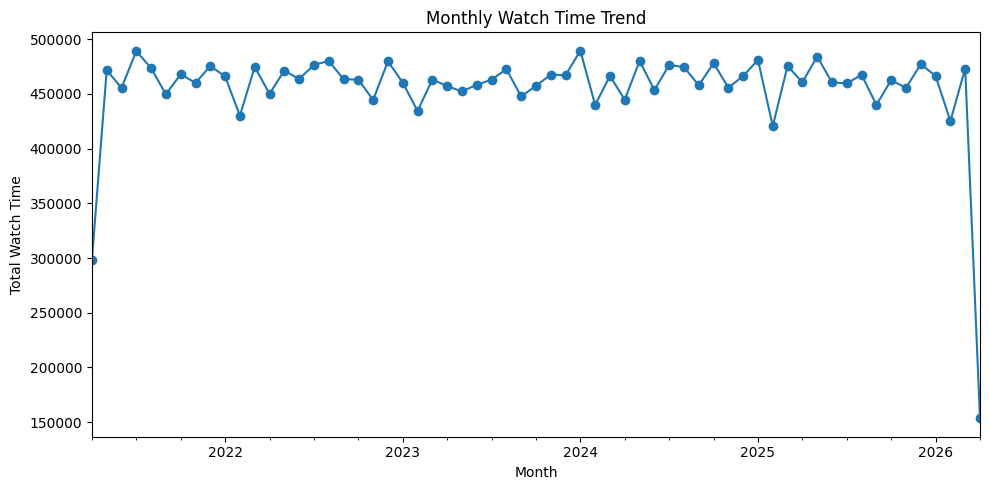

In [56]:
# monthly trend
monthly_trend = full_df.resample('M', on='watch_date')['watch_time_minutes'].sum()

plt.figure(figsize=(10,5))
monthly_trend.plot(marker='o')
plt.title('Monthly Watch Time Trend')
plt.xlabel('Month')
plt.ylabel('Total Watch Time')
plt.tight_layout()
plt.show()

In [59]:
!pip install scikit-learn

In [67]:
from sklearn.linear_model import LinearRegression
import numpy as np
# Monthly trend
monthly_trend = full_df.resample('ME', on='watch_date')['watch_time_minutes'].sum()

monthly_trend = monthly_trend.reset_index()
monthly_trend['month_num'] = np.arange(len(monthly_trend))

X = monthly_trend[['month_num']]
y = monthly_trend['watch_time_minutes']

# Model
model = LinearRegression()
model.fit(X, y)

# Future prediction (FIXED)
future_months = pd.DataFrame({
    'month_num': np.arange(len(monthly_trend), len(monthly_trend)+3)
})

predictions = model.predict(future_months)
print(predictions)

[445752.12436066 445456.72843046 445161.33250026]


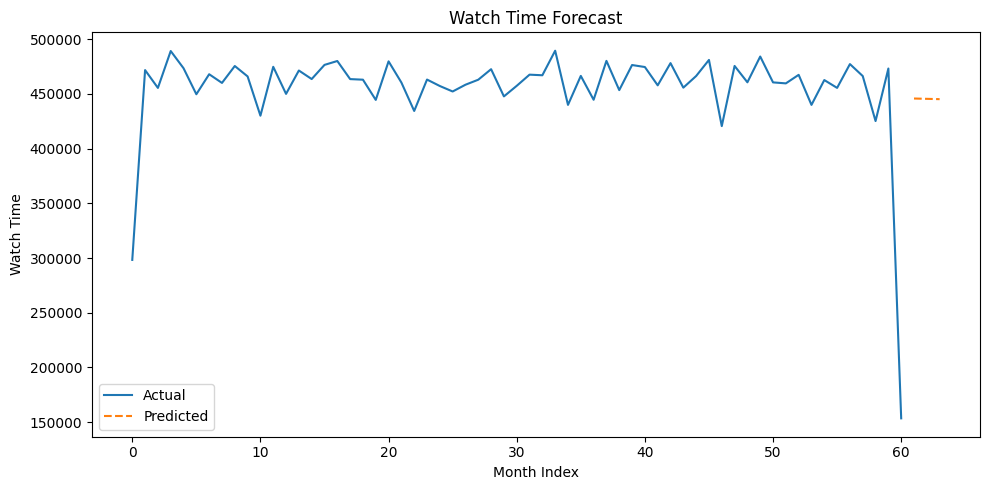

In [68]:
plt.figure(figsize=(10,5))

plt.plot(monthly_trend['month_num'], y, label='Actual')
plt.plot(future_months, predictions, linestyle='--', label='Predicted')

plt.title('Watch Time Forecast')
plt.xlabel('Month Index')
plt.ylabel('Watch Time')
plt.legend()
plt.tight_layout()
plt.show()